In [1]:
#Importing necessary libraries
import numpy as np
import matplotlib.pyplot as plt
from sympy.physics.mechanics import dynamicsymbols
from scipy.integrate import solve_ivp
from scipy.linalg import solve_continuous_are
import matplotlib.animation as animation

In [ ]:
#System physical parameters
m = 1.0         # Mass at the end of the pole
M = 5.0         # Mass of the cart
g = 9.81        # Gravity
L = 0.75        # Length of pole
F_MAX = 20.0    # Max force motor is capable of

#Solving for gain matrix for LQR by hand
A = np.array([[0, 1, 0, 0],
              [0, 0, m*g/M, 0],
              [0, 0, 0, 1],
              [0, 0, (M+m)*g/(M*L), 0]])
 
B = np.array([0, 1/M, 0, 1/(M*L)]).reshape(-1, 1)

Q = np.diag([0.1, 1, 50, 400])

R = np.array([[1/F_MAX**2]])

P = solve_continuous_are(A, B, Q, R)
K = np.linalg.inv(R) @ B.T @ P
K = K.flatten()

#Keeps angle within [-pi, pi]
def wrap_angle(theta):
    angle = (theta + np.pi) % (2*np.pi) - np.pi
    return angle

In [129]:
#Controller Parameters
hand_off_theta = np.radians(25)
hand_off_thd = np.radians(120)
Ke = 1.5
target = np.array([0, 0, np.pi, 0])     # Desired state is [x=0, x_dot=0, theta=pi, theta_dot=0]

def lqr_controller(state):
    error = state - target  
    error[2] = wrap_angle(error[2])
    F = -K @ error
    F = np.clip(F, -F_MAX, F_MAX)   #Motor saturation, small default force to help stationary start
    return F

#Uses angular velocity and angle error to calculate force
def heuristic_swingup(state):
    F = -F_MAX * np.sign(state[3] * np.cos(state[2]))
    if np.sign(F) == np.sign(state[0]):
        F = F * 0.2  # Reduce the force if the cart is moving in the same direction as the position error
    F = np.clip(F + 0.001, -F_MAX, F_MAX)
    return F

#Energy-based swingup method
def energy_swingup(state):
    error = state - target
    error[2] = wrap_angle(error[2])
    KE = 0.5 * m * (L * state[3])**2
    PE = -m*g*L*np.cos(state[2])
    E = KE + PE
    E_desired = 1.2*m*g*L
    E_error = E - E_desired

    F = Ke * (E_error) * state[3] * np.cos(state[2])
    F = np.clip(F, -F_MAX, F_MAX)
    return F

def hybrid_controller(state, mode="energy"):
    error = state - target
    error[2] = wrap_angle(error[2])

    if abs(error[2]) < hand_off_theta:
        return lqr_controller(state)
    
    if mode == "heuristic":
        if abs(state[3]) < hand_off_thd:
            return heuristic_swingup(state)
        else:
            return lqr_controller(state)
        
    elif mode == "energy":
        return energy_swingup(state)

forces = []
#Simulation function
def derivatives(t, state):
    x, x_dot, theta, theta_dot = state
    F = hybrid_controller(state)
    forces.append(F)
    print(f"Time Step: {t}  Force applied: {F}")
    s, c = np.sin(theta), np.cos(theta)
    denom = M + m * s**2
    x_ddot = (F + m * s * (L * theta_dot**2 + g * c)) / denom
    theta_ddot = (-(M + m)*g*s - F*c - m*L*s*c*theta_dot**2) / (L * denom)
    return [x_dot, x_ddot, theta_dot, theta_ddot]

Time Step: 0.0  Force applied: -0.0
Time Step: 0.0006214116043241185  Force applied: 0.004131856267008817
Time Step: 0.004914443258173612  Force applied: 0.0326768480097042
Time Step: 0.007371664887260418  Force applied: 0.05018448640381103
Time Step: 0.019657773032694448  Force applied: 0.13943533707574984
Time Step: 0.021841970036327162  Force applied: 0.15638936009336593
Time Step: 0.02457221629086806  Force applied: 0.1773539720810263
Time Step: 0.02457221629086806  Force applied: 0.1768132542173284
Time Step: 0.04687717615988325  Force applied: 0.34990583851917034
Time Step: 0.05802965609439085  Force applied: 0.4630113415879986
Time Step: 0.11379205576692884  Force applied: 1.0992011472441283
Time Step: 0.12370537126426892  Force applied: 1.2657472387888595
Time Step: 0.13609701563594404  Force applied: 1.4319951113322689
Time Step: 0.13609701563594404  Force applied: 1.3831747180637373
Time Step: 0.15845106617473703  Force applied: 1.7030565727502718
Time Step: 0.169628091444133

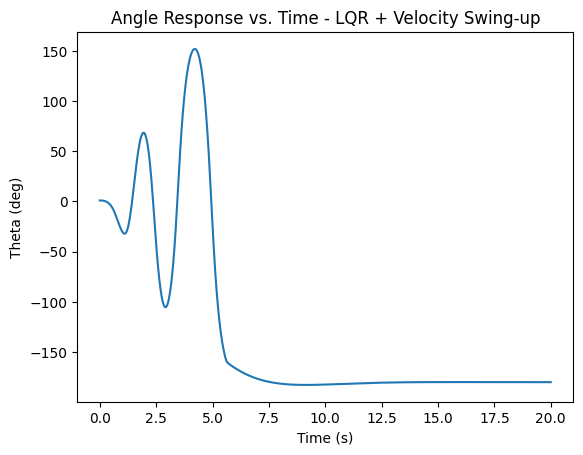

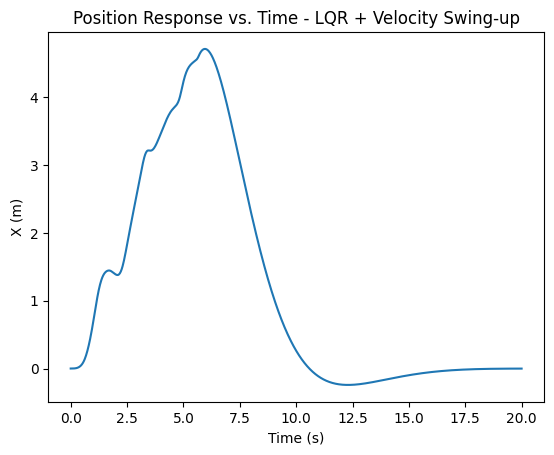

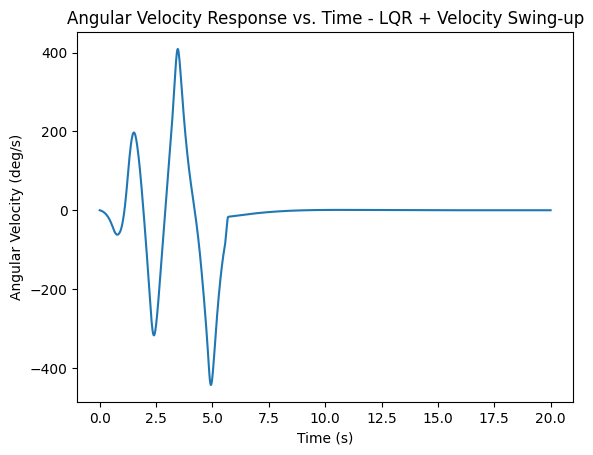

In [134]:
#Setting initial state and running simulation with control
theta0 = np.radians(1)
theta_dot0 = np.radians(0)
x0 = 0.0
x_dot0 = 0.0
state0 = [x0, x_dot0, theta0, theta_dot0]

t_end = 20
fps = 50
t_eval = np.linspace(0, t_end, t_end*fps)

sol = solve_ivp(derivatives, [0, t_end], state0, t_eval=t_eval, rtol=1e-6, atol=1e-6)
x, x_dot, theta, theta_dot = sol.y
t = sol.t

plt.plot(t, np.degrees(theta))
plt.xlabel('Time (s)')
plt.ylabel('Theta (deg)')
plt.title("Angle Response vs. Time - LQR + Velocity Swing-up")
plt.show()

plt.plot(t, x)
plt.xlabel('Time (s)')
plt.ylabel('X (m)')
plt.title("Position Response vs. Time - LQR + Velocity Swing-up")
plt.show()

plt.plot(t, np.degrees(theta_dot))
plt.xlabel('Time (s)')
plt.ylabel('Angular Velocity (deg/s)')
plt.title("Angular Velocity Response vs. Time - LQR + Velocity Swing-up")
plt.show()

13026


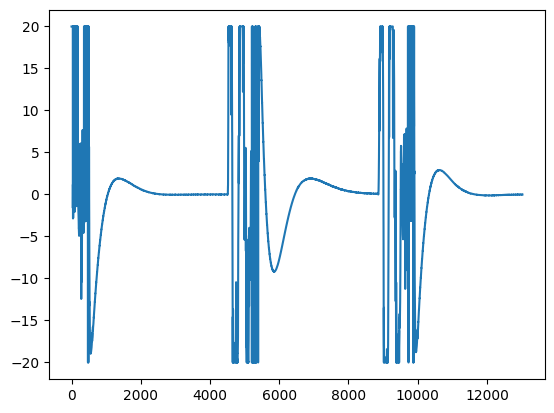

In [135]:
plt.plot(forces)
print(len(forces))

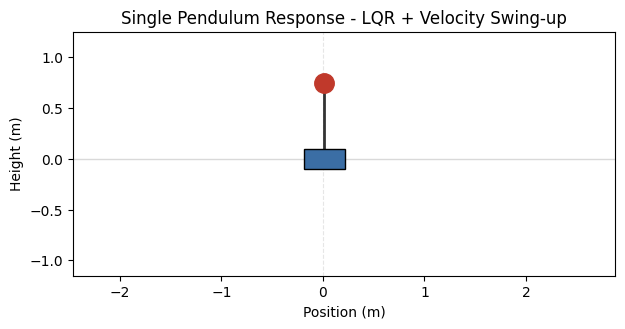

In [29]:
#Animating Pendulum Response

bob_x = x + L * np.sin(theta)
bob_y = -L * np.cos(theta)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.set_xlim(x.min() - L - 0.4, x.max() + L + 0.4)
ax.set_ylim(-L - 0.4, L + 0.5)
ax.set_aspect('equal')
ax.axhline(0, color='0.85', lw=1)
ax.axvline(0, color='0.9', lw=0.8, ls='--')      # cart target position
ax.set_title("Single Pendulum Response - LQR + Velocity Swing-up")
ax.set_xlabel("Position (m)")
ax.set_ylabel("Height (m)")
 
cart_w, cart_h = 0.4, 0.2
cart = plt.Rectangle((0, -cart_h/2), cart_w, cart_h, fc='#3b6ea5', ec='k', zorder=3)
ax.add_patch(cart)
rod,   = ax.plot([], [], '-', color='#333', lw=2, zorder=2)
bob,   = ax.plot([], [], 'o', color='#c0392b', ms=14, zorder=4)
 
def animate(i):
    cx = x[i]
    cart.set_xy((cx - cart_w/2, -cart_h/2))
    rod.set_data([cx, bob_x[i]], [0, bob_y[i]])
    bob.set_data([bob_x[i]], [bob_y[i]])
    scale = 0.06
    return cart, rod, bob

ani = animation.FuncAnimation(fig, animate, frames=len(t_eval),
                              interval=1000/fps, blit=True)

writer = animation.FFMpegWriter(fps=fps, codec='libx264',
                                extra_args=['-preset', 'ultrafast', '-pix_fmt', 'yuv420p'])
ani.save("../figures/single_pendulum_LQR.mp4", writer=writer, dpi=200)